# Lab 4 — Assignment


**Based on:** Lab-4-b (Bernoulli, Binomial, Poisson, Normal, Uniform)


---

### Instructions

1. Run the **Setup** cell first. Do not modify it.
2. There are **10 questions** — two on each distribution. Attempt **all** of them.
3. Every question has three parts:
   - **(a)** and **(b)** — work these out **by hand** and type your working in the *Written answer* cell.
   - **(c)** — write **Python code** in the blank code cell provided and produce the plot asked for.
4. Use `DISCRETE_COLOR` for discrete plots (bars) and `CONTINUOUS_COLOR` for continuous plots (curves).
5. Every plot must have an **x-label, y-label and a title**. Marks are deducted for unlabelled plots.
6. Round all probabilities to **4 decimal places**.
7. Save the notebook with all outputs visible before submitting.

### Marks distribution

| Section | Questions | Marks each | Total |
|---|---|---|---|
| A — Bernoulli | Q1, Q2 | 5 | 10 |
| B — Binomial | Q3, Q4 | 5 | 10 |
| C — Poisson | Q5, Q6 | 5 | 10 |
| D — Normal | Q7, Q8 | 5 | 10 |
| E — Uniform | Q9, Q10 | 5 | 10 |
| | | **Total** | **50** |

### Quick reference — which function do I need?

| Task | `scipy.stats` call |
|---|---|
| $P(X = k)$, discrete | `.pmf(k, ...)` |
| $f(x)$, continuous | `.pdf(x, ...)` |
| $P(X \le x)$ | `.cdf(x, ...)` |
| $P(X > x)$ | `.sf(x, ...)` |
| Value with given $P(X \le x)$ | `.ppf(prob, ...)` |
| Mean / variance | `.mean(...)`, `.var(...)` |
| Random samples | `.rvs(..., size=n, random_state=seed)` |

---

## Setup
Run this cell first — do not change it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import comb, factorial, exp, sqrt

DISCRETE_COLOR = "#0E9F9A"     # teal   -> discrete distributions
CONTINUOUS_COLOR = "#E4572E"   # orange -> continuous distributions
HIGHLIGHT_COLOR = "#F4A261"    # use this to highlight a bar or a shaded area

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Setup complete — you are ready to start.")

Setup complete — you are ready to start.


---
# Part A — Bernoulli distribution
*Recall:* $P(X=x) = p^x(1-p)^{1-x}$ for $x \in \{0,1\}$, $\;E[X]=p$, $\;Var(X)=p(1-p)$.

## Q1. The library gate scanner 

> 📚 The RFID gate at the college library reads a student's ID card correctly on the **first tap 92%** of the time. One student taps her card once.
>
> Let $X = 1$ if the card is read on the first tap, and $X = 0$ if it is not.
>
> **(a)** State the value of $p$ and find $P(X=1)$ and $P(X=0)$.
> **(b)** Find the mean and the variance of $X$, showing the substitution into the formulas.
> **(c)** Write Python code that:
> - builds the PMF of $X$ using `stats.bernoulli.pmf`,
> - draws a **bar chart** of the distribution in `DISCRETE_COLOR` with the ticks labelled `"Not read (0)"` and `"Read (1)"`,
> - writes the probability value on top of each bar,
> - prints the mean and the variance obtained from `scipy`, and checks that they match your hand answers in (b).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> Given:

$$ p=0.92 $$

For a Bernoulli random variable,

$$ P(X=x)=p^x(1-p)^{1-x} $$

For \(X=1\):

$$ P(X=1)=0.92 $$

For \(X=0\):

$$ P(X=0)=1-0.92=0.08 $$

(b)

Mean:

$$ E(X)=p=0.92 $$

Variance:

$$ Var(X)=p(1-p) $$
=0.92(0.08)=0.0736
> 
> 
> 
> 


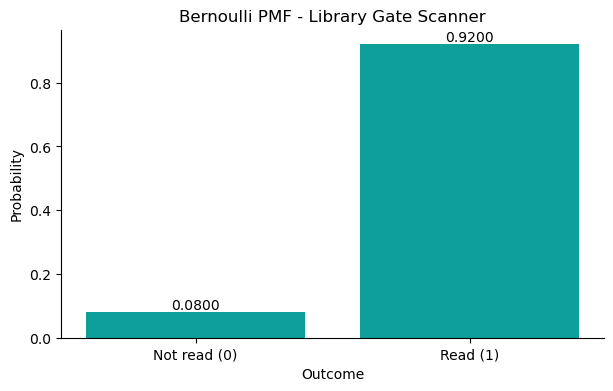

Mean = 0.9200
Variance = 0.0736
Hand-calculated mean = 0.9200
Hand-calculated variance = 0.0736


In [2]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
p = 0.92
x = np.array([0, 1])

pmf = stats.bernoulli.pmf(x, p)

plt.figure()
plt.bar(x, pmf, color=DISCRETE_COLOR)
plt.xticks(x, ["Not read (0)", "Read (1)"])
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.title("Bernoulli PMF - Library Gate Scanner")

for i, value in enumerate(pmf):
    plt.text(i, value + 0.01, f"{value:.4f}", ha="center")

plt.show()

mean = stats.bernoulli.mean(p)
variance = stats.bernoulli.var(p)

print(f"Mean = {mean:.4f}")
print(f"Variance = {variance:.4f}")

print(f"Hand-calculated mean = {p:.4f}")
print(f"Hand-calculated variance = {p*(1-p):.4f}")
# ------------------------------------------------------------

## Q2. Estimating $p$ from attendance data &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 👆 A biometric attendance device records whether a student's fingerprint is accepted on the **first attempt**. Over one semester the device logged **2,000 scans**, of which **1,740** were accepted on the first attempt. Treat one scan as a single Bernoulli trial with $X=1$ for *accepted*.
>
> **(a)** Estimate $p$ from the data and write down the full PMF $P(X=x)$ with the estimated value substituted in.
> **(b)** Find the mean and variance. Then answer: for what value of $p$ would the variance of a Bernoulli variable be the **largest possible**, and what is that largest value? Justify your answer using the formula $Var(X)=p(1-p)$.
> **(c)** Write Python code that:
> - simulates 2,000 Bernoulli trials with your estimated $p$ using `stats.bernoulli.rvs(..., random_state=42)`,
> - prints the **simulated proportion** of successes next to the theoretical $p$,
> - plots the **theoretical PMF and the simulated relative frequencies side by side** as grouped bars with a legend,
> - plots $Var(X)=p(1-p)$ against $p$ for $p$ from 0 to 1 in a **second figure**, and marks the maximum point with a marker and an annotation.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> (a)

Estimated probability:

$$ \hat p=\frac{1740}{2000}=0.87 $$

Therefore,

$$ P(X=x)=(0.87)^x(0.13)^{1-x} $$

So,

$$ P(X=1)=0.87 $$ $$ P(X=0)=0.13 $$

(b)

Mean:

$$ E(X)=p=0.87 $$

Variance:

$$ Var(X)=p(1-p) $$ $$ =0.87(0.13)=0.1131 $$

For maximum variance:

$$ Var(X)=p(1-p) $$

The maximum occurs at:

$$ p=0.5 $$

Therefore,

Var(X)=0.5(0.5)=0.25
> 
> 
> 
> 


Theoretical p = 0.8700
Simulated proportion of successes = 0.8675


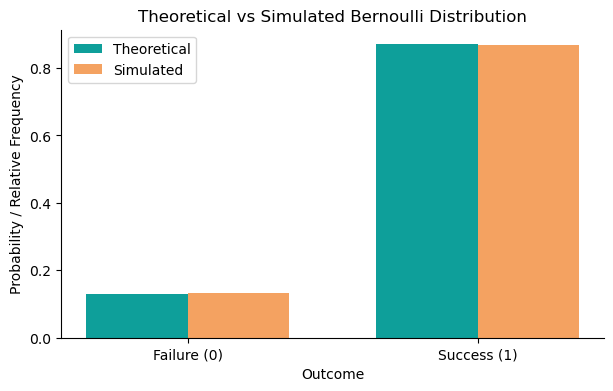

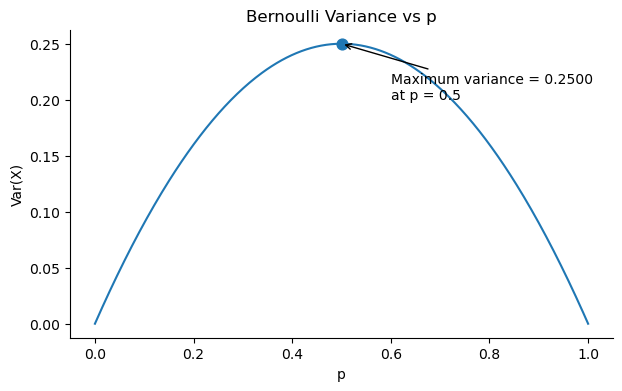

In [10]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
n = 2000
successes = 1740

p_hat = successes / n

simulated = stats.bernoulli.rvs(p_hat, size=n, random_state=42)

simulated_proportion = np.mean(simulated)

print(f"Theoretical p = {p_hat:.4f}")
print(f"Simulated proportion of successes = {simulated_proportion:.4f}")

x = np.array([0, 1])
theoretical_pmf = stats.bernoulli.pmf(x, p_hat)

simulated_freq = np.array([
    np.mean(simulated == 0),
    np.mean(simulated == 1)
])

width = 0.35

plt.figure()
plt.bar(x - width/2, theoretical_pmf, width,
        label="Theoretical", color=DISCRETE_COLOR)
plt.bar(x + width/2, simulated_freq, width,
        label="Simulated", color=HIGHLIGHT_COLOR)

plt.xticks(x, ["Failure (0)", "Success (1)"])
plt.xlabel("Outcome")
plt.ylabel("Probability / Relative Frequency")
plt.title("Theoretical vs Simulated Bernoulli Distribution")
plt.legend()
plt.show()

p_values = np.linspace(0, 1, 400)
variance_values = p_values * (1 - p_values)

max_variance = 0.25

plt.figure()
plt.plot(p_values, variance_values)
plt.scatter(0.5, max_variance, s=60)
plt.annotate(
    "Maximum variance = 0.2500\nat p = 0.5",
    xy=(0.5, max_variance),
    xytext=(0.6, 0.20),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("p")
plt.ylabel("Var(X)")
plt.title("Bernoulli Variance vs p")
plt.show()
# ------------------------------------------------------------

---
# Part B — Binomial distribution
*Recall:* $P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$, $\;E[X]=np$, $\;Var(X)=np(1-p)$.

## Q3. Guessing a multiple-choice quiz &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📝 An online quiz has **12 multiple-choice questions**, each with **4 options** and exactly one correct answer. A student who has not studied guesses every answer at random. Let $X$ = number of questions answered correctly.
>
> **(a)** State $n$ and $p$, check that the **BINS** conditions hold, and compute $P(X=5)$ **by hand**, showing the value of $\binom{12}{5}$.
> **(b)** Find the mean and the variance of $X$.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
>

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> (a)

$$ n=12,\qquad p=0.25 $$

The BIN(S) conditions hold because:

Fixed number of trials: \(n=12\)
Each trial has two outcomes: correct/incorrect
Probability of success is constant: \(p=0.25\)
Trials are assumed independent.

For \(X=5\):

$$ P(X=5)=\binom{12}{5}(0.25)^5(0.75)^7 $$ $$ \binom{12}{5}=\frac{12!}{5!7!}=792 $$

Therefore,

$$ P(X=5)=792(0.25)^5(0.75)^7 $$ $$ P(X=5)\approx0.1032 $$

(b)

Mean:

$$ E(X)=np $$ $$ =12(0.25)=3 $$

Variance:

$$ Var(X)=np(1-p) $$
=12(0.25)(0.75)=2.25
> 
> 
> 
> 


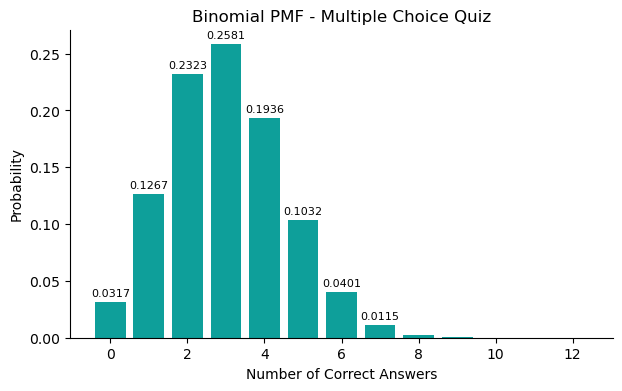

P(X = 5) = 0.1032
Mean = 3.0000
Variance = 2.2500


In [11]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
n = 12
p = 0.25

x = np.arange(0, n + 1)

pmf = stats.binom.pmf(x, n, p)

plt.figure()
plt.bar(x, pmf, color=DISCRETE_COLOR)
plt.xlabel("Number of Correct Answers")
plt.ylabel("Probability")
plt.title("Binomial PMF - Multiple Choice Quiz")

for i, value in enumerate(pmf):
    if value > 0.005:
        plt.text(i, value + 0.005, f"{value:.4f}",
                 ha="center", fontsize=8)

plt.show()

mean = stats.binom.mean(n, p)
variance = stats.binom.var(n, p)

prob_5 = stats.binom.pmf(5, n, p)

print(f"P(X = 5) = {prob_5:.4f}")
print(f"Mean = {mean:.4f}")
print(f"Variance = {variance:.4f}")
# ------------------------------------------------------------

#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


---
# Part C — Poisson distribution
*Recall:* $P(X=k) = \dfrac{\lambda^k e^{-\lambda}}{k!}$, $\;E[X]=Var(X)=\lambda$.

## Q5. Help-desk emails &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📧 The IT help-desk of a college receives on average **3 emails per hour**. Let $X$ = number of emails received in one hour.
>
> **(a)** Compute $P(X = 0)$ and $P(X = 2)$ **by hand**, showing the substitution into the formula ($e^{-3} \approx 0.0498$).
> **(b)** State the mean and the variance, and explain in one line what is special about them for a Poisson distribution.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
> - prints $P(X=0)$, $P(X=2)$ and $P(X \le 5)$,
> - prints the smallest value of $k$ for which $P(X \le k) \ge 0.95$ (use `.ppf` or a loop).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> (a)

Poisson PMF:

$$ P(X=k)=\frac{\lambda^k e^{-\lambda}}{k!} $$

For \(X=0\):

$$ P(X=0)=\frac{3^0e^{-3}}{0!} $$ $$ =e^{-3}\approx0.0498 $$

For \(X=2\):

$$ P(X=2)=\frac{3^2e^{-3}}{2!} $$ $$ =\frac{9e^{-3}}{2} $$ $$ \approx0.2240 $$

(b)

For Poisson:

$$ E(X)=\lambda=3 $$
Var(X)=λ=3
> 
> 
> 


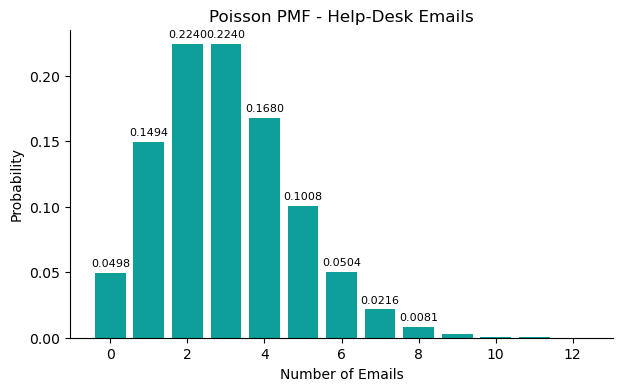

P(X = 0) = 0.0498
P(X = 2) = 0.2240
P(X <= 5) = 0.9161
Smallest k with P(X <= k) >= 0.95: 6
P(X <= 6) = 0.9665


In [12]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
lam = 3

k = np.arange(0, 13)

pmf = stats.poisson.pmf(k, lam)

plt.figure()
plt.bar(k, pmf, color=DISCRETE_COLOR)
plt.xlabel("Number of Emails")
plt.ylabel("Probability")
plt.title("Poisson PMF - Help-Desk Emails")

for i, value in enumerate(pmf):
    if value > 0.005:
        plt.text(i, value + 0.005, f"{value:.4f}",
                 ha="center", fontsize=8)

plt.show()

p0 = stats.poisson.pmf(0, lam)
p2 = stats.poisson.pmf(2, lam)
p_le_5 = stats.poisson.cdf(5, lam)

print(f"P(X = 0) = {p0:.4f}")
print(f"P(X = 2) = {p2:.4f}")
print(f"P(X <= 5) = {p_le_5:.4f}")

k_95 = stats.poisson.ppf(0.95, lam)

print(f"Smallest k with P(X <= k) >= 0.95: {int(k_95)}")
print(f"P(X <= {int(k_95)}) = {stats.poisson.cdf(int(k_95), lam):.4f}")
# ------------------------------------------------------------

## Q6. Server errors over a night shift &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 🖥️ A web server logs errors at an average rate of **1.5 errors per hour**. The night shift runs from 10 pm to 6 am, i.e. **8 hours**.
>
> **(a)** Find the value of $\lambda$ for the **whole 8-hour shift**, and compute by hand the probability of a **clean shift** (zero errors in the 8 hours).
> **(b)** State the mean and variance for the 8-hour window. The on-call engineer is paged if **more than 18 errors** occur in the shift — write the expression for that probability and name the `scipy` function that gives it directly.
> **(c)** Write Python code that:
> - creates **two subplots side by side** — the PMF for the 1-hour window ($\lambda = 1.5$) and the PMF for the 8-hour window — each with its own sensible range of $k$, title and labels,


#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> (a)

$$ \lambda_{8hr}=1.5\times8=12 $$

Clean shift means zero errors:

$$ P(X=0)=\frac{12^0e^{-12}}{0!} $$ $$ =e^{-12} $$ $$ \approx0.000006 $$

(b)

Mean:

$$ E(X)=12 $$

Variance:

$$ Var(X)=12 $$

More than 18 errors:

$$ P(X>18) $$

Using SciPy survival function:

P(X>18)=poisson.sf(18,12)
> 
> 
> 
> 


Lambda for 1-hour window = 1.5000
Lambda for 8-hour window = 12.0000
P(X = 0) for 8-hour shift = 0.0000
Mean for 8-hour shift = 12.0000
Variance for 8-hour shift = 12.0000
P(X > 18) = 0.0374


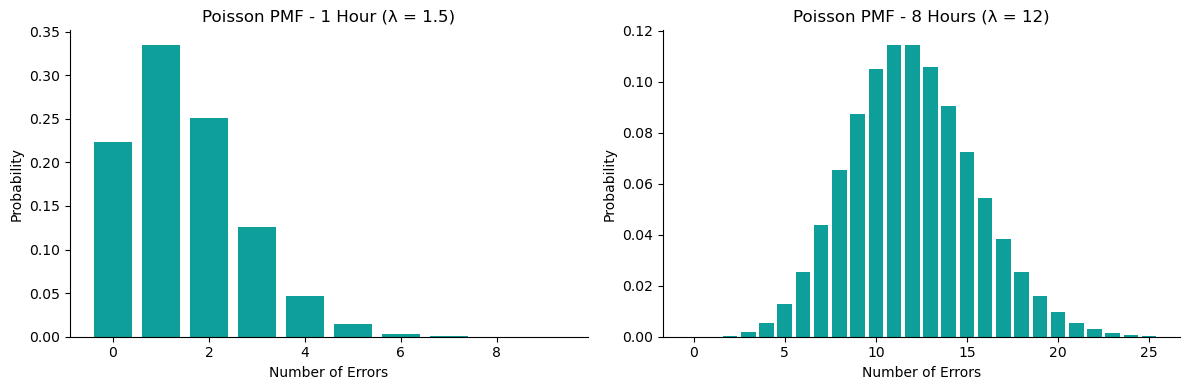

In [13]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
lam_1hr = 1.5
hours = 8
lam_8hr = lam_1hr * hours

clean_shift = stats.poisson.pmf(0, lam_8hr)

prob_more_18 = stats.poisson.sf(18, lam_8hr)

print(f"Lambda for 1-hour window = {lam_1hr:.4f}")
print(f"Lambda for 8-hour window = {lam_8hr:.4f}")
print(f"P(X = 0) for 8-hour shift = {clean_shift:.4f}")
print(f"Mean for 8-hour shift = {stats.poisson.mean(lam_8hr):.4f}")
print(f"Variance for 8-hour shift = {stats.poisson.var(lam_8hr):.4f}")
print(f"P(X > 18) = {prob_more_18:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

k1 = np.arange(0, 10)
pmf1 = stats.poisson.pmf(k1, lam_1hr)

axes[0].bar(k1, pmf1, color=DISCRETE_COLOR)
axes[0].set_xlabel("Number of Errors")
axes[0].set_ylabel("Probability")
axes[0].set_title("Poisson PMF - 1 Hour (λ = 1.5)")

k2 = np.arange(0, 26)
pmf2 = stats.poisson.pmf(k2, lam_8hr)

axes[1].bar(k2, pmf2, color=DISCRETE_COLOR)
axes[1].set_xlabel("Number of Errors")
axes[1].set_ylabel("Probability")
axes[1].set_title("Poisson PMF - 8 Hours (λ = 12)")

plt.tight_layout()
plt.show()
# ------------------------------------------------------------

---
# Part D — Normal distribution
*Recall:* $f(x)=\dfrac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/2\sigma^2}$, $\;Z=\dfrac{X-\mu}{\sigma}$, $\;E[X]=\mu$, $\;Var(X)=\sigma^2$.

## Q7. Battery life of a phone &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🔋 The battery life of a phone model is normally distributed with a mean of **18 hours** and a standard deviation of **1.5 hours**. Let $X$ = battery life of a randomly chosen phone.
>
> **(a)** Compute the **Z-score** for a battery life of 15 hours and say in words what that Z-score means.
> **(b)** Using the 68–95–99.7 rule, state the interval of battery lives that contains about **95%** of the phones. Show how you obtained it.
> **(c)** Write Python code that:
> - generates 400 equally spaced values of $x$ over $\mu \pm 4\sigma$ and computes the PDF,
> - plots the curve in `CONTINUOUS_COLOR` with a title and axis labels,
.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> (a)

For \(X=15\):

$$ Z=\frac{X-\mu}{\sigma} $$ $$ Z=\frac{15-18}{1.5} $$ $$ Z=\frac{-3}{1.5}=-2 $$

So the battery life of 15 hours is 2 standard deviations below the mean.

(b)

Using the 68-95-99.7 rule, approximately 95% lies within:

$$ \mu\pm2\sigma $$ $$ =18\pm2(1.5) $$ $$ =18\pm3 $$

Therefore:

15≤X≤21
	​

> 
> 
> 
> 


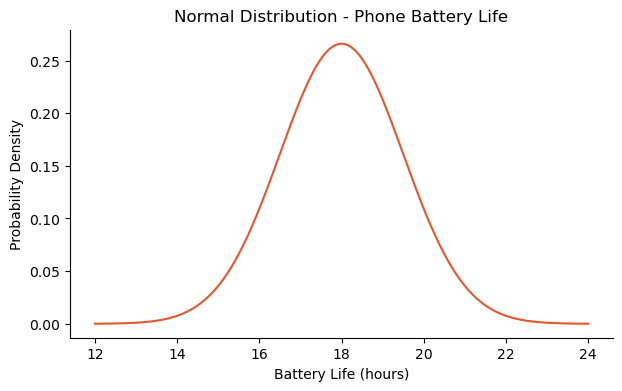

Z-score for 15 hours = -2.0000
Approximate 95% interval = [15.0000, 21.0000] hours


In [14]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
mu = 18
sigma = 1.5

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)

pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.figure()
plt.plot(x, pdf, color=CONTINUOUS_COLOR)
plt.xlabel("Battery Life (hours)")
plt.ylabel("Probability Density")
plt.title("Normal Distribution - Phone Battery Life")
plt.show()

z = (15 - mu) / sigma

lower = mu - 2*sigma
upper = mu + 2*sigma

print(f"Z-score for 15 hours = {z:.4f}")
print(f"Approximate 95% interval = [{lower:.4f}, {upper:.4f}] hours")
# ------------------------------------------------------------

## Q8. Calibrating a coffee machine &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> ☕ A vending machine fills cups with coffee. The fill volume is normally distributed with a mean of **200 ml**, but the standard deviation is **not known**. The service log shows that **2.5% of cups overflow**, which happens whenever the fill exceeds **210 ml**.
>
> **(a)** Using the standard normal value $z_{0.975} \approx 1.96$, find the standard deviation $\sigma$ of the fill volume. Show the working.
> **(b)** With that $\sigma$, find the volume below which only **1%** of cups fall (the 1st percentile), and state which `scipy` function gives it. A customer complains if the cup holds less than **190 ml** — write the expression for that probability.
> **(c)** Write Python code that:
> - computes $\sigma$ using `stats.norm.ppf` rather than the rounded 1.96,
> - plots the PDF over a sensible range in `CONTINUOUS_COLOR`,



#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> Using:

$$ z_{0.975}\approx1.96 $$ $$ z=\frac{x-\mu}{\sigma} $$ $$ 1.96=\frac{210-200}{\sigma} $$ $$ 1.96=\frac{10}{\sigma} $$

Therefore:

$$ \sigma=\frac{10}{1.96} $$ $$ \boxed{\sigma\approx5.1020\text{ ml}} $$

For the 1st percentile:

$$ P(X\leq x)=0.01 $$

Using the standard normal value:

$$ z_{0.01}\approx-2.3263 $$ $$ x=\mu+z\sigma $$ $$ x=200+(-2.3263)(5.1020) $$
x≈188.13 ml
	​

> 
> 
> 
> 


Exact z_0.975 = 1.9600
Calculated sigma = 5.1021 ml
1st percentile = 188.1307 ml
P(X < 190) = 0.0250


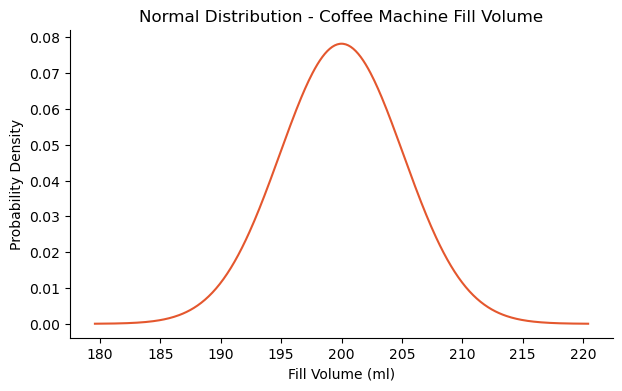

In [15]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
mu = 200
overflow_volume = 210
overflow_probability = 0.025

z_975 = stats.norm.ppf(1 - overflow_probability)

sigma = (overflow_volume - mu) / z_975

print(f"Exact z_0.975 = {z_975:.4f}")
print(f"Calculated sigma = {sigma:.4f} ml")

first_percentile = stats.norm.ppf(0.01, loc=mu, scale=sigma)

prob_less_190 = stats.norm.cdf(190, loc=mu, scale=sigma)

print(f"1st percentile = {first_percentile:.4f} ml")
print(f"P(X < 190) = {prob_less_190:.4f}")

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.figure()
plt.plot(x, pdf, color=CONTINUOUS_COLOR)
plt.xlabel("Fill Volume (ml)")
plt.ylabel("Probability Density")
plt.title("Normal Distribution - Coffee Machine Fill Volume")
plt.show()
# ------------------------------------------------------------

---
# Part E — Uniform distribution
*Recall:* $f(x)=\dfrac{1}{b-a}$ for $a \le x \le b$, $\;P(c \le X \le d)=\dfrac{d-c}{b-a}$, $\;E[X]=\dfrac{a+b}{2}$, $\;Var(X)=\dfrac{(b-a)^2}{12}$.

⚠️ **Note on `scipy`:** for a uniform distribution on $[a, b]$ you must use `loc=a` and `scale=b-a`, **not** `loc=a, scale=b`.

## Q9. Waiting for the campus shuttle &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🚌 The campus shuttle leaves the gate exactly every **15 minutes**. A student walks up to the stop at a completely random moment, so her waiting time $X$ is uniformly distributed between **0 and 15 minutes**.
>

> **(a)** Find the mean waiting time and the variance, showing the substitution.
> **(b)** Write Python code that:
> - plots the PDF as a flat line/rectangle over $[0, 15]$ in `CONTINUOUS_COLOR` (extend the x-axis a little beyond the range so the flat top is clear),


#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> Mean:

$$ E(X)=\frac{a+b}{2} $$ $$ =\frac{0+15}{2} $$ $$ =\boxed{7.5\text{ minutes}} $$

Variance:

$$ Var(X)=\frac{(b-a)^2}{12} $$ $$ =\frac{(15-0)^2}{12} $$ $$ =\frac{225}{12} $$
=
18.75 minutes
2
	​

> 
> 
> 
> 


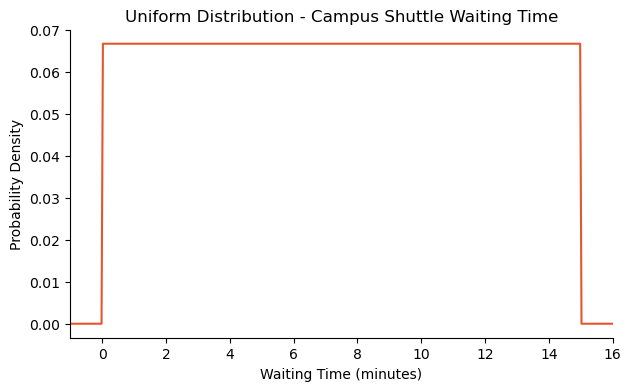

Mean waiting time = 7.5000 minutes
Variance = 18.7500 minutes^2


In [16]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
a = 0
b = 15

x = np.linspace(-1, 16, 400)

pdf = stats.uniform.pdf(x, loc=a, scale=b-a)

plt.figure()
plt.plot(x, pdf, color=CONTINUOUS_COLOR)
plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Probability Density")
plt.title("Uniform Distribution - Campus Shuttle Waiting Time")
plt.xlim(-1, 16)
plt.show()

mean = stats.uniform.mean(loc=a, scale=b-a)
variance = stats.uniform.var(loc=a, scale=b-a)

print(f"Mean waiting time = {mean:.4f} minutes")
print(f"Variance = {variance:.4f} minutes^2")
# ------------------------------------------------------------